In [1]:
# WEB DEV TEAM PLEASE DELETE BEFORE PUBLISHING - DS TEAM PLEASE KEEP IN THE FINAL VERSION OF THE USE CASE

from IPython.core.display import HTML
HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');
body,p,li,div{font-family:'Inter',sans-serif}
body{counter-reset:h2counter}
.usecase-header-bar,.usecase-title,.usecase-section-heading,.usecase-sub-section-heading,.usecase-sub-sub-section-heading,.usecase-unnumbered-heading{font-family:'Poppins',sans-serif}
.usecase-header-bar{padding:16px 20px;background-color:#059669;color:#fff;border-radius:6px 6px 0 0}
.usecase-title{font-size:1.9em;font-weight:800}
.usecase-details{padding-left:20px;padding-bottom:8px;padding-top:8px;font-size:1.1em;color:#121212}
.usecase-section-heading,.usecase-unnumbered-heading{font-weight:700;font-size:1.35em;color:#059669;padding:14px 4px 6px 4px;border-bottom:3px solid #2DBE6C;margin-top:10px}
.usecase-section-heading::before{content:none!important}
.usecase-sub-section-heading{font-weight:600;font-size:1.15em;color:#059669;margin-top:8px}
.usecase-sub-section-heading::before{content:none!important}
.usecase-sub-sub-section-heading{font-weight:500;font-size:1.05em;color:#059669;margin-top:6px}
.usecase-sub-sub-section-heading::before{content:none!important}
.usecase-body{font-size:1em;color:#121212;line-height:1.6;margin-bottom:8px}
.usecase-list{line-height:1.7}
.usecase-list ul,.usecase-list ol{padding-left:24px;margin-top:8px;margin-bottom:12px}
.usecase-list li{margin-bottom:6px}
.usecase-datasets{background-color:rgba(5,150,105,.06);border-left:4px solid #059669;padding:12px 20px;border-radius:0 4px 4px 0;margin-top:12px}
.usecase-datasets ul{margin-top:8px;margin-bottom:8px}
.usecase-contents a,.usecase-datasets a{color:#059669;text-decoration:none}
.usecase-datasets a{font-weight:500}
.usecase-contents a:hover,.usecase-datasets a:hover{text-decoration:underline}
.usecase-contents{line-height:1.9;padding-left:20px}
</style>
""")

<div class="usecase-header-bar">
    <div class="usecase-title">Melbourne Live Parking Availability</div>
</div>

<div class="usecase-details"><b>Authored by: </b>Siju Deng</div>
<div class="usecase-details"><b>Date Created: </b>Trimester 1, 2024</div>
<div class="usecase-details"><b>Time to Complete:</b> 90 mins</div>
<div class="usecase-details"><b>Level: </b>Intermediate</div>
<div class="usecase-details"><b>Pre-requisite Skills: </b>Python, Data Wrangling</div>

<div id="scenario" class="usecase-unnumbered-heading"><b>Scenario</b></div>

<div class="usecase-body">As someone who drives into Melbourne regularly, I want to avoid the frustration of circling the city looking for a park. Before I set off, I want to know which parts of the city are currently hardest to park in, and whether those areas are still filling up or have started to clear.</div>

<div class="usecase-body">Throughout this use case, a <b>hotspot</b> means an area of the city where a high number of nearby parking bays are occupied at the same time — in other words, somewhere a driver is unlikely to find a space. The term is used in this sense consistently from here on.</div>

<div class="usecase-body">This use case draws on the City of Melbourne's live parking sensor feed to answer the following questions:</div>

<div class="usecase-list">

- Where are the parking hotspots in the city right now?
- Are those hotspots still building, or have they started to ease?

</div>

<div id="what-this-teaches" class="usecase-unnumbered-heading"><b>What this use case will teach you</b></div>

<div class="usecase-body">By the end of this use case you will be able to:</div>

<div class="usecase-list">

- Retrieve and combine several related datasets from the City of Melbourne Open Data API
- Recognise and work with snapshot data, where each record only reflects the most recent state
- Clean and validate real sensor data, including duplicates, outdated records and timezone handling
- Merge datasets that are maintained by different departments and do not align cleanly
- Apply DBSCAN clustering to identify geographic hotspots
- Build static and interactive visualisations of parking activity across the city

</div>

<div id="background" class="usecase-unnumbered-heading"><b>Background</b></div>

<div class="usecase-body">Parking in central Melbourne is managed through in-ground sensors that report whether a bay is currently occupied or vacant. The City of Melbourne publishes this sensor feed as open data, alongside separate datasets describing the physical parking bays and the restrictions that apply to them. Together these can be used to build a picture of where parking pressure is concentrated across the city.</div>

<div class="usecase-body">The sensor feed itself is live: at any moment it reflects which bays are currently occupied and which are free. What it does not provide is history. Each sensor only reports its most recent state, and when that state changes the previous record is replaced rather than kept, so there is no time series to draw on. This means current availability can be read directly from the data, while anything about how hotspots build up over the course of a day has to be reconstructed from a single point-in-time snapshot.</div>

<div class="usecase-body">This shapes what can be claimed. The analysis below is exploratory: it combines three datasets that are maintained by different departments and do not align perfectly, makes explicit assumptions where data is missing, and produces a theoretical view of how hotspots form rather than a verified one. Sensor faults, roadworks and gaps in the restriction data all affect accuracy, and results will differ depending on when the notebook is run. It is best read as a worked example of handling messy, incomplete real-world data rather than as a production parking service.</div>

<div id="data-sets" class="usecase-unnumbered-heading"><b>Data Sets</b></div>

<div class="usecase-body">Three datasets from the City of Melbourne Open Data platform are used, each retrieved through the v2.1 export API. They are maintained separately, which is why a good portion of this use case is spent reconciling them.</div>

<div class="usecase-datasets">

- <a href="https://data.melbourne.vic.gov.au/explore/dataset/on-street-parking-bay-sensors/information/">On-street Parking Bay Sensors</a> — the live sensor feed giving each bay's current occupied or vacant status.
- <a href="https://data.melbourne.vic.gov.au/explore/dataset/on-street-parking-bays/information/">On-street Parking Bays</a> — the physical parking bays, used to link sensors to a bay identifier.
- <a href="https://data.melbourne.vic.gov.au/explore/dataset/on-street-car-park-bay-restrictions/information/">On-street Car Park Bay Restrictions</a> — the restrictions and time limits that apply to each bay.

</div>

<div id="contents" class="usecase-unnumbered-heading"><b>Contents</b></div>

<div class="usecase-contents">

<ol>
<li><a href="#section-1">Set up the Python environment</a></li>
<li><a href="#section-2">Retrieve the parking sensor data</a></li>
<li><a href="#section-3">Preparing and validating the sensor data</a>
<div style="margin-left:24px;">3.1. <a href="#subsection-3-1">Separate latitude and longitude</a></div>
<div style="margin-left:24px;">3.2. <a href="#subsection-3-2">Check for missing values and data types</a></div>
<div style="margin-left:24px;">3.3. <a href="#subsection-3-3">Remove outdated records</a></div>
<div style="margin-left:24px;">3.4. <a href="#subsection-3-4">Remove duplicate records</a></div>
</li>
<li><a href="#section-4">Exploring what the sensor data actually contains</a>
<div style="margin-left:24px;">4.1. <a href="#subsection-4-1">Count the unique parking spaces</a></div>
<div style="margin-left:24px;">4.2. <a href="#subsection-4-2">Locations reporting more than one record</a></div>
<div style="margin-left:24px;">4.3. <a href="#subsection-4-3">Check for duplicate kerbside IDs</a></div>
<div style="margin-left:24px;">4.4. <a href="#subsection-4-4">Earliest recorded vacancy per space</a></div>
<div style="margin-left:24px;">4.5. <a href="#subsection-4-5">Spaces vacated in the last few hours</a></div>
<div style="margin-left:24px;">4.6. <a href="#subsection-4-6">What this tells us about the data</a></div>
</li>
<li><a href="#section-5">Converting to Melbourne local time</a>
<div style="margin-left:24px;">5.1. <a href="#subsection-5-1">Convert the timestamps</a></div>
<div style="margin-left:24px;">5.2. <a href="#subsection-5-2">Select the analysis date</a></div>
<div style="margin-left:24px;">5.3. <a href="#subsection-5-3">Check the time range covered</a></div>
<div style="margin-left:24px;">5.4. <a href="#subsection-5-4">Spaces reporting multiple statuses</a></div>
</li>
<li><a href="#section-6">Visualising the day's parking activity</a>
<div style="margin-left:24px;">6.1. <a href="#subsection-6-1">Map of all sensors</a></div>
<div style="margin-left:24px;">6.2. <a href="#subsection-6-2">Distribution of update times</a></div>
<div style="margin-left:24px;">6.3. <a href="#subsection-6-3">Update times split by status</a></div>
</li>
<li><a href="#section-7">Adding parking bay restrictions</a>
<div style="margin-left:24px;">7.1. <a href="#subsection-7-1">Retrieve the parking bay dataset</a></div>
<div style="margin-left:24px;">7.2. <a href="#subsection-7-2">Merge bays onto the sensor data</a></div>
<div style="margin-left:24px;">7.3. <a href="#subsection-7-3">Retrieve the restriction descriptions</a></div>
<div style="margin-left:24px;">7.4. <a href="#subsection-7-4">Merge the restrictions</a></div>
<div style="margin-left:24px;">7.5. <a href="#subsection-7-5">Separate out disabled parking bays</a></div>
<div style="margin-left:24px;">7.6. <a href="#subsection-7-6">How complete is the restriction data?</a></div>
</li>
<li><a href="#section-8">Estimating parking hotspots</a>
<div style="margin-left:24px;">8.1. <a href="#subsection-8-1">Estimating when each space was taken</a></div>
<div style="margin-left:24px;">8.2. <a href="#subsection-8-2">Popular parking hours</a></div>
<div style="margin-left:24px;">8.3. <a href="#subsection-8-3">Clustering the hotspots on a map</a></div>
</li>
</ol>

</div>

<div id="section-1" class="usecase-section-heading"><b>1. Set up the Python environment</b></div>

<div class="usecase-body">Import the libraries used throughout this use case, covering data retrieval, data wrangling, timezone handling, clustering and both static and interactive mapping.</div>

In [2]:
import requests
import pytz
import folium
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from datetime import datetime
from pandas.tseries.offsets import Minute
from sklearn.cluster import DBSCAN

<div id="section-2" class="usecase-section-heading"><b>2. Retrieve the parking sensor data</b></div>

<div class="usecase-body">The sensor feed is retrieved from the City of Melbourne Open Data v2.1 export API as CSV. This dataset does not require an API key. The request asks for all records rather than a page at a time, and timestamps are returned in UTC, which is converted to Melbourne time later in section 5.</div>

In [3]:
# On-street parking bay sensors - the live occupied/vacant feed
dataset_id = 'on-street-parking-bay-sensors'
base_URL = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
format = 'csv'

url = f'{base_URL}{dataset_id}/exports/{format}'
params = {
    'select': '*',
    'limit': -1,  # all records
    'lang': 'en',
    'timezone': 'UTC',
}

# GET request
response = requests.get(url, params = params)

if response.status_code == 200:
    # StringIO to read the CSV data
    url_content = response.content.decode('utf-8')
    df = pd.read_csv(StringIO(url_content), delimiter = ';')
    print(df.sample(2, random_state = 999))    # test
else:
    print(f'Request failed with status code {response.status_code}')

                    lastupdated           status_timestamp  zone_number  \
3942  2026-08-24T04:31:40+00:00  2026-08-15T21:11:11+00:00       7009.0   
1024  2026-08-24T04:31:40+00:00  2026-08-24T04:21:34+00:00       7693.0   

     status_description  kerbsideid                               location  
3942         Unoccupied       16862   -37.800498946205, 144.95864306080105  
1024            Present       54718  -37.81020086201354, 144.9586364036427  


In [4]:
# check length in dataset
print(f'The dataset contains {len(df)} records.')

The dataset contains 6324 records.


<div class="usecase-body">The record count gives a first sense of scale. Because this is a snapshot feed rather than a history, this number is roughly the number of sensors currently reporting rather than a growing log of events.</div>

<div id="section-3" class="usecase-section-heading"><b>3. Preparing and validating the sensor data</b></div>

<div class="usecase-body">Before any analysis, the raw feed needs cleaning. The location arrives as a single combined string, timestamps arrive as text, and the feed contains both stale records and duplicates. Each is dealt with in turn below.</div>

<div id="subsection-3-1" class="usecase-sub-section-heading"><b>3.1. Separate latitude and longitude</b></div>

<div class="usecase-body">The API returns the position of each sensor as one comma-separated <code>location</code> string. Splitting it into separate numeric latitude and longitude columns is what makes the mapping and clustering later in the notebook possible.</div>

In [5]:
print(df.dtypes)

lastupdated            object
status_timestamp       object
zone_number           float64
status_description     object
kerbsideid              int64
location               object
dtype: object


In [6]:
# Split the location string into latitude and longitude, then assign to new columns
df['latitude'] = df['location'].apply(lambda x: float(x.split(',')[0].strip()))
df['longitude'] = df['location'].apply(lambda x: float(x.split(',')[1].strip()))

# Drop the original location column
df.drop(columns = ['location'], inplace=True)

In [7]:
print(df.head(3))

                 lastupdated           status_timestamp  zone_number  \
0  2025-05-08T05:44:34+00:00  2025-04-14T03:01:40+00:00       7218.0   
1  2025-05-08T05:44:34+00:00  2024-03-06T20:13:57+00:00          NaN   
2  2025-05-08T05:44:34+00:00  2025-04-13T20:29:07+00:00       7219.0   

  status_description  kerbsideid   latitude   longitude  
0         Unoccupied       57940 -37.820270  144.954583  
1            Present       23372 -37.818698  144.955738  
2            Present       69943 -37.822505  144.952164  


<div id="subsection-3-2" class="usecase-sub-section-heading"><b>3.2. Check for missing values and data types</b></div>

<div class="usecase-body">This check runs before any filtering so that problems are caught early rather than surfacing halfway through the analysis. It looks for missing values, duplicate rows and incorrect data types — in particular whether the timestamp columns are still stored as text, which would make any time-based comparison fail silently.</div>

In [8]:
def validate_data(df):
    print("\nChecking for NaN values:")
    print(df.isna().sum())
    print("\nChecking for Duplicates:")
    print(df.duplicated().sum())
    print("\nChecking data types:")
    print(df.dtypes)

validate_data(df)


Checking for NaN values:
lastupdated             0
status_timestamp        0
zone_number           529
status_description      0
kerbsideid              0
latitude                0
longitude               0
dtype: int64

Checking for Duplicates:
0

Checking data types:
lastupdated            object
status_timestamp       object
zone_number           float64
status_description     object
kerbsideid              int64
latitude              float64
longitude             float64
dtype: object


<div id="subsection-3-3" class="usecase-sub-section-heading"><b>3.3. Remove outdated records</b></div>

<div class="usecase-body">Zone numbers are left untouched, as they do not affect either the sensor position or its identifier. The timestamps do need attention: some sensors report readings that are long out of date, usually because the sensor has failed or the bay has been closed off. Records older than one year are treated as stale and removed so they do not distort the analysis.</div>

In [9]:
# Define the function to convert columns to datetime
def convert_to_datetime(df, column_name):
    try:
        df[column_name] = pd.to_datetime(df[column_name], errors = 'coerce', format = "%Y-%m-%dT%H:%M:%S+00:00")
    except ValueError as e:
        print(f"Error converting {column_name}: {e}")

In [10]:
# Create a new DataFrame for analysis based on the original df
df_analysis = df.copy()

# Apply the datetime conversion function
convert_to_datetime(df_analysis, 'lastupdated')
convert_to_datetime(df_analysis, 'status_timestamp')

# Check for NaT values in datetime columns
nat_counts = df_analysis[['lastupdated', 'status_timestamp']].isna().sum()
print("NaT values after conversion:")
print(nat_counts)

NaT values after conversion:
lastupdated         0
status_timestamp    0
dtype: int64


In [11]:
# Identify the most recent timestamp
latest_timestamp = df_analysis['status_timestamp'].max()

# Calculate the date one year ago from the most recent timestamp
one_year_ago = latest_timestamp - pd.DateOffset(years=1)

# Filter and process as per your previous logic
outdated_rows = df_analysis[df_analysis['status_timestamp'] < one_year_ago].copy()

print("Outdated rows:")
print(outdated_rows.sort_values(by = 'status_timestamp').head())

# Print the data header sorted by 'status_timestamp'
print("\nData header sorted by time:")
print(df_analysis.sort_values(by = 'status_timestamp').head())

Outdated rows:
             lastupdated    status_timestamp  zone_number status_description  \
2197 2025-10-30 02:45:40 2022-09-13 04:38:23       7247.0         Unoccupied   
4843 2026-08-24 04:31:40 2022-11-20 03:44:07       7725.0         Unoccupied   
2172 2025-10-27 00:15:39 2022-11-29 23:10:24       7258.0         Unoccupied   
1944 2026-08-24 04:31:40 2022-12-30 12:40:42       7766.0         Unoccupied   
3408 2026-08-24 04:31:40 2023-01-13 23:58:09          NaN            Present   

      kerbsideid   latitude   longitude  
2197       17512 -37.810928  144.976544  
4843        9587 -37.803845  144.949580  
2172       23027 -37.810538  144.978320  
1944       12076 -37.800909  144.953274  
3408        6547 -37.809835  144.958634  

Data header sorted by time:
             lastupdated    status_timestamp  zone_number status_description  \
2197 2025-10-30 02:45:40 2022-09-13 04:38:23       7247.0         Unoccupied   
4843 2026-08-24 04:31:40 2022-11-20 03:44:07       7725.0      

In [12]:
# Delete outdated rows
df_analysis = df_analysis[df_analysis['status_timestamp'] >= one_year_ago]

In [13]:
df_analysis.shape

(5370, 7)

<div id="subsection-3-4" class="usecase-sub-section-heading"><b>3.4. Remove duplicate records</b></div>

<div class="usecase-body">Because the export is retrieved in a single bulk request, the same sensor reading can appear more than once. Duplicates are identified on the combination of kerbside ID, status, position and update time, then removed. Skipping this step would inflate every count that follows.</div>

In [14]:
# Detect duplicates based on all columns
duplicates = df_analysis.duplicated(
    subset = ['kerbsideid', 'status_description', 'latitude', 'longitude'],
    keep = False)

# Display duplicates
print("Duplicate Rows based on all columns are:")
print(df_analysis[duplicates].sort_values('kerbsideid'))

Duplicate Rows based on all columns are:
Empty DataFrame
Columns: [lastupdated, status_timestamp, zone_number, status_description, kerbsideid, latitude, longitude]
Index: []


In [15]:
# Remove duplicates based on specified columns in df_analysis
df_analysis.drop_duplicates(
    subset = ['kerbsideid', 'status_description',
              'latitude', 'longitude', 'lastupdated'],
    keep = 'first', inplace = True)

<div id="section-4" class="usecase-section-heading"><b>4. Exploring what the sensor data actually contains</b></div>

<div class="usecase-body">This section builds an understanding of how the sensor feed behaves before relying on it. The checks below are less about producing results and more about establishing what the data can and cannot support — which turns out to shape every decision made later in the notebook.</div>

<div id="subsection-4-1" class="usecase-sub-section-heading"><b>4.1. Count the unique parking spaces</b></div>

<div class="usecase-body">Counting distinct positions establishes how many physical parking spaces the feed actually covers, which is the baseline for everything that follows.</div>

In [16]:
# Drop duplicate rows based on 'latitude' and 'longitude'
unique_locations = df_analysis.drop_duplicates(subset = ['latitude', 'longitude'])

# Count the number of unique parking spaces based on location
total_unique_parking_spaces = len(unique_locations)

print(f"The total number of unique parking spaces based on location is {total_unique_parking_spaces}.")

The total number of unique parking spaces based on location is 5246.


<div id="subsection-4-2" class="usecase-sub-section-heading"><b>4.2. Locations reporting more than one record</b></div>

<div class="usecase-body">If a single position appears more than once, it suggests either a duplicate that survived cleaning or one sensor covering more than one bay. Distinguishing between the two matters, because the first is a data quality problem while the second is simply how the sensors are installed.</div>

In [17]:
# Group by latitude and longitude and count occurrences in df_analysis
location_counts = df_analysis.groupby(
    ['latitude', 'longitude']).size().reset_index(name = 'Occurrences')

# Identify locations that appear more than once in df_analysis
duplicate_locations = location_counts[location_counts['Occurrences'] > 1]

# Print out the duplicate locations in df_analysis
if duplicate_locations.empty:
    print("Each geographic location occurs only once.")
else:
    print("Duplicate geographic locations found:")
    print(duplicate_locations)

Duplicate geographic locations found:
       latitude   longitude  Occurrences
1505 -37.815511  144.982564            2
1510 -37.815459  144.982573            2
1515 -37.815407  144.982582            2
1521 -37.815355  144.982591            2
1524 -37.815304  144.982599            2
...         ...         ...          ...
3070 -37.810023  144.975705            2
3083 -37.809990  144.975710            2
3095 -37.809958  144.975716            2
3109 -37.809925  144.975721            2
3121 -37.809893  144.975726            2

[124 rows x 3 columns]


<div class="usecase-body">Looking at the kerbside IDs attached to those repeated positions shows which of the two explanations applies.</div>

In [18]:
# Filter rows in df_analysis where geographic locations are duplicated
duplicate_locations = df_analysis[
    df_analysis.duplicated(subset = ['latitude', 'longitude'], keep = False)]

# Sort these rows in df_analysis by latitude, longitude, and kerbsideid for easier inspection
sorted_duplicates = duplicate_locations.sort_values(
    by = ['latitude', 'longitude', 'kerbsideid'])

# Print kerbsideid for duplicate locations in df_analysis
print("Kerbside id for duplicate locations:")
print(sorted_duplicates[['latitude', 'longitude', 'kerbsideid']])

Kerbside id for duplicate locations:
       latitude   longitude  kerbsideid
2227 -37.815511  144.982564       25055
6266 -37.815511  144.982564       87764
178  -37.815459  144.982573       25056
1863 -37.815459  144.982573       87765
177  -37.815407  144.982582       25057
...         ...         ...         ...
4129 -37.809958  144.975716       86422
4364 -37.809925  144.975721       17430
6211 -37.809925  144.975721       86423
4353 -37.809893  144.975726       17429
6206 -37.809893  144.975726       86424

[248 rows x 3 columns]


<div id="subsection-4-3" class="usecase-sub-section-heading"><b>4.3. Check for duplicate kerbside IDs</b></div>

<div class="usecase-body">The kerbside ID is used to join the sensor feed to the bay and restriction datasets in section 7, so it needs to be unique. If the same ID appeared twice, that join would silently multiply rows.</div>

In [19]:
# df_analysis is DataFrame for analysis
duplicate_kerbsideid = df_analysis[df_analysis['kerbsideid'].duplicated(keep = False)]

# Sort the data in df_analysis for easier inspection
duplicate_kerbsideids = duplicate_kerbsideid.sort_values('kerbsideid')

if len(duplicate_kerbsideid) > 0:
    print("Duplicate kerbsideid found in df_analysis:")
    print(duplicate_kerbsideid[['kerbsideid', 'latitude', 'longitude']])
else:
    print("No duplicate kerbsideid found in df_analysis.")

No duplicate kerbsideid found in df_analysis.


<div id="subsection-4-4" class="usecase-sub-section-heading"><b>4.4. Earliest recorded vacancy per space</b></div>

<div class="usecase-body">For each space that is currently vacant, this finds the earliest vacancy reading held for it. It gives a sense of how long spaces have been sitting empty according to the feed, and how far back the snapshot reaches.</div>

In [20]:
# Filter for 'Unoccupied' status in df_analysis
unoccupied_spaces = df_analysis[df_analysis['status_description'] == 'Unoccupied']

# Sort by 'status_timestamp' in df_analysis
sorted_unoccupied = unoccupied_spaces.sort_values(by = 'status_timestamp')

# Find the earliest time for each unique parking space based on latitude and longitude in df_analysis
earliest_unoccupied = sorted_unoccupied.drop_duplicates(
    subset = ['latitude', 'longitude'], keep = 'first')

# Display the result
print("The earliest time each parking space was detected as empty in df_analysis:")
print(earliest_unoccupied[['latitude', 'longitude', 'status_timestamp']])

The earliest time each parking space was detected as empty in df_analysis:
       latitude   longitude    status_timestamp
6156 -37.807239  144.954901 2025-08-24 10:26:37
5266 -37.814731  144.961799 2025-08-24 11:26:15
2065 -37.804085  144.955467 2025-08-24 23:43:40
2066 -37.804060  144.955472 2025-08-25 02:56:09
6160 -37.807090  144.954929 2025-08-25 03:54:47
...         ...         ...                 ...
6057 -37.803821  144.961767 2026-08-24 04:28:46
3366 -37.826758  144.966459 2026-08-24 04:28:47
4852 -37.812606  144.973741 2026-08-24 04:28:48
3068 -37.811155  144.957487 2026-08-24 04:28:53
803  -37.814144  144.959793 2026-08-24 04:28:54

[2851 rows x 3 columns]


<div id="subsection-4-5" class="usecase-sub-section-heading"><b>4.5. Spaces vacated in the last few hours</b></div>

<div class="usecase-body">This looks for spaces that are vacant now but were reported as occupied within the previous three hours, which would indicate genuine turnover rather than a bay that has sat empty all day.</div>

<div class="usecase-body">The original version of this step looped over every vacant space one at a time, filtering the whole dataset and appending to a growing DataFrame on each iteration. That pattern is very slow on a dataset this size, because each append copies the entire result so far. The version below does the same thing as a single vectorised join: every vacant reading is paired with occupied readings at the same position, the pairs are filtered to the three-hour window before the space became vacant, and the most recent occupied time is kept for each location.</div>

In [21]:
# Vectorised replacement for the original row-by-row loop.
vacant = df_analysis.loc[
    df_analysis['status_description'] == 'Unoccupied',
    ['latitude', 'longitude', 'status_timestamp']
]
occupied = df_analysis.loc[
    df_analysis['status_description'] == 'Present',
    ['latitude', 'longitude', 'status_timestamp']
]

# Pair every vacant reading with the occupied readings at the same position
pairs = vacant.merge(
    occupied, on = ['latitude', 'longitude'], suffixes = ('_vacant', '_occupied')
)

# Keep only occupied readings from the three hours immediately before the space became vacant
within_window = (
    (pairs['status_timestamp_occupied'] >= pairs['status_timestamp_vacant'] - pd.Timedelta(hours = 3)) &
    (pairs['status_timestamp_occupied'] <= pairs['status_timestamp_vacant'])
)

result = (
    pairs[within_window]
    .groupby(['latitude', 'longitude'], as_index = False)['status_timestamp_occupied']
    .max()
    .rename(columns = {'status_timestamp_occupied': 'last_occupied_time'})
)

print("Parking spaces that were occupied a few hours ago and are now vacant:")
print(result)

Parking spaces that were occupied a few hours ago and are now vacant:
Empty DataFrame
Columns: [latitude, longitude, last_occupied_time]
Index: []


<div id="subsection-4-6" class="usecase-sub-section-heading"><b>4.6. What this tells us about the data</b></div>

<div class="usecase-list">

- Very few sensors report both statuses, and some positions carry two bay IDs. This is expected: the position recorded is the sensor location, and a single sensor can cover two adjacent bays.
- The feed is confirmed as snapshot data. When a sensor reports a change, the previous state is replaced rather than retained, so there is no history to analyse.
- Because sensors are checked each morning, the current day's readings are the most reliable. Older readings are more likely to reflect faults or closures than real parking activity.

</div>

<div class="usecase-body">This is the key constraint shaping the rest of the notebook: with no history available, parking activity has to be estimated from a single snapshot rather than measured directly.</div>

<div id="section-5" class="usecase-section-heading"><b>5. Converting to Melbourne local time</b></div>

<div class="usecase-body">The API returns timestamps in UTC, but the question being asked — when hotspots form during the day — only makes sense in local time. Melbourne is 10 to 11 hours ahead of UTC depending on daylight saving, so leaving the data in UTC would shift every hourly result and place the apparent hotspot activity in the wrong part of the day.</div>

<div id="subsection-5-1" class="usecase-sub-section-heading"><b>5.1. Convert the timestamps</b></div>

<div class="usecase-body">The current time is established in both UTC and Melbourne time, then the sensor timestamps are localised and converted so that every later comparison happens in local time.</div>

In [22]:
# Create a timezone object for Melbourne
melbourne_tz = pytz.timezone('Australia/Melbourne')

# Get the current time in UTC
current_time_utc = datetime.now(pytz.utc)

# Convert to Melbourne local time
current_time_melbourne = current_time_utc.astimezone(melbourne_tz)

print(f"Current time in UTC: {current_time_utc}")
print(f"Current time in Melbourne: {current_time_melbourne}")

Current time in UTC: 2026-08-24 04:33:21.018143+00:00
Current time in Melbourne: 2026-08-24 14:33:21.018143+10:00


In [23]:
# Check if 'status_timestamp' is timezone-naive
if df_analysis['status_timestamp'].dt.tz is None:
    # Localize naive datetime objects to UTC
    df_analysis['status_timestamp'] = df_analysis['status_timestamp'].dt.tz_localize('UTC')
else:
    # If already timezone-aware, ensure it's in UTC
    df_analysis['status_timestamp'] = df_analysis['status_timestamp'].dt.tz_convert('UTC')

# Convert 'status_timestamp' from UTC to Melbourne local time
df_analysis['status_timestamp'] = df_analysis['status_timestamp'].dt.tz_convert('Australia/Melbourne')

# Display the first few 'status_timestamp' to check
print(df_analysis['status_timestamp'].head())

120   2025-10-20 19:10:02+11:00
121   2025-10-20 19:14:52+11:00
122   2025-10-20 17:35:18+11:00
123   2025-10-20 19:07:08+11:00
124   2025-10-20 15:26:44+11:00
Name: status_timestamp, dtype: datetime64[ns, Australia/Melbourne]


<div id="subsection-5-2" class="usecase-sub-section-heading"><b>5.2. Select the analysis date</b></div>

<div class="usecase-body">The analysis focuses on a single day, since that is the only portion of the feed considered reliable. Rather than assuming the calendar date will always be present, the code checks whether today has any records and falls back to the most recent available date if not. Without this fallback the notebook breaks whenever it is run at a time when no readings have been published for the current date — for example late at night, just after midnight, or when the feed is briefly stale — leaving every downstream cell working from an empty table.</div>

In [24]:
print("Unique dates in the dataset:", df_analysis['status_timestamp'].dt.date.unique())

# Convert 'status_timestamp' to date only for filtering
df_analysis['status_date'] = df_analysis['status_timestamp'].dt.date

# Today's date in Melbourne, taken from the timezone-aware current time
today_melbourne = current_time_melbourne.date()
print("Today's date in Melbourne:", today_melbourne)

# Fall back to the most recent date in the data if today has no records yet,
# so the notebook still runs whenever it is executed.
available_dates = df_analysis['status_date'].dropna().unique()

if today_melbourne in available_dates:
    analysis_date = today_melbourne
else:
    analysis_date = max(available_dates)
    print(f"No records found for today ({today_melbourne}). "
          f"Using the most recent available date instead: {analysis_date}.")

print("Analysis date:", analysis_date)

# .copy() avoids a SettingWithCopyWarning when new columns are added to this subset later
todays_data = df_analysis[df_analysis['status_date'] == analysis_date].copy()

print(f"There are {len(todays_data)} rows in the data for {analysis_date}.")

Unique dates in the dataset: [datetime.date(2025, 10, 20) datetime.date(2025, 10, 30)
 datetime.date(2025, 10, 23) datetime.date(2025, 10, 14)
 datetime.date(2025, 10, 2) datetime.date(2025, 11, 13)
 datetime.date(2025, 12, 18) datetime.date(2025, 11, 24)
 datetime.date(2025, 10, 15) datetime.date(2026, 1, 15)
 datetime.date(2026, 1, 14) datetime.date(2025, 9, 3)
 datetime.date(2026, 3, 10) datetime.date(2026, 3, 9)
 datetime.date(2026, 1, 26) datetime.date(2026, 7, 21)
 datetime.date(2026, 7, 22) datetime.date(2026, 7, 20)
 datetime.date(2026, 7, 5) datetime.date(2026, 8, 20)
 datetime.date(2026, 8, 19) datetime.date(2026, 7, 13)
 datetime.date(2026, 8, 23) datetime.date(2026, 8, 24)
 datetime.date(2025, 11, 8) datetime.date(2026, 2, 8)
 datetime.date(2026, 3, 24) datetime.date(2026, 8, 16)
 datetime.date(2025, 12, 15) datetime.date(2026, 3, 25)
 datetime.date(2026, 7, 6) datetime.date(2026, 3, 20)
 datetime.date(2026, 2, 28) datetime.date(2026, 7, 29)
 datetime.date(2026, 1, 18) date

<div id="subsection-5-3" class="usecase-sub-section-heading"><b>5.3. Check the time range covered</b></div>

<div class="usecase-body">Knowing the earliest and latest readings for the selected day shows how much of the day the snapshot actually covers. A narrow range means any hourly pattern found later reflects only part of the day.</div>

In [25]:
if not todays_data.empty:
    min_timestamp_today = todays_data['status_timestamp'].min()
    max_timestamp_today = todays_data['status_timestamp'].max()
    print(f"The data for {analysis_date} ranges from {min_timestamp_today} to {max_timestamp_today}.")
else:
    print("No data available for the selected date to determine the time range.")

The data for 2026-08-24 ranges from 2026-08-24 00:44:27+10:00 to 2026-08-24 14:28:54+10:00.


<div id="subsection-5-4" class="usecase-sub-section-heading"><b>5.4. Spaces reporting multiple statuses</b></div>

<div class="usecase-body">If any space reports more than one status on the same day, it has genuinely turned over rather than sitting in a single state. Given the snapshot nature of the feed this should be rare, and confirming that is what justifies the assumption made in section 8.</div>

In [26]:
if todays_data.empty:
    print("No data available for today's analysis.")
else:
    # Group by unique identifier for each parking space and count unique statuses
    status_counts = todays_data.groupby(
        ['latitude', 'longitude'])['status_description'].nunique().reset_index(
            name = 'Unique_Status_Count')

    # Filter for parking spaces with more than one unique status
    multiple_statuses = status_counts[status_counts['Unique_Status_Count'] > 1]

    # Display the result
    if multiple_statuses.empty:
        print("No parking spaces with multiple statuses found for today.")
    else:
        print("Parking spaces with multiple statuses found for today:")
        print(multiple_statuses)

No parking spaces with multiple statuses found for today.


<div id="section-6" class="usecase-section-heading"><b>6. Visualising the day's parking activity</b></div>

<div class="usecase-body">With a clean single-day dataset in place, the next step is to look at where the sensors are and when they report, which starts to answer whether hotspots are currently building or already easing.</div>

<div id="subsection-6-1" class="usecase-sub-section-heading"><b>6.1. Map of all sensors</b></div>

<div class="usecase-body">Every sensor reporting on the selected day is plotted on an interactive map, coloured by whether the bay is currently vacant or occupied. Clicking a marker shows its status and last update time.</div>

In [27]:
# Initialize the map centered around Melbourne's CBD
m = folium.Map(location = [-37.814, 144.963], zoom_start = 16)

# Add points to the map using the selected day's data
for idx, row in todays_data.iterrows():
    color = "#059669" if row['status_description'] == "Unoccupied" else "#F97316"
    popup_text = f"Status: {row['status_description']}<br>Updated: {row['status_timestamp']}"
    folium.CircleMarker(
        location = [row['latitude'], row['longitude']],
        radius = 1,
        color = color,
        fill = True,
        fill_color = color,
        popup = popup_text
    ).add_to(m)

legend_html = """
<div style="position: fixed;
            bottom: 40px; left: 40px; width: 190px;
            background-color: rgba(255, 255, 255, 0.9); border:2px solid grey; z-index:1000; font-size:14px;
            padding: 10px;">
<b>Bay status</b><br>
<i style="background:#059669; width:10px; height:10px; display:inline-block; border-radius:50%;"></i>&nbsp;Unoccupied<br>
<i style="background:#F97316; width:10px; height:10px; display:inline-block; border-radius:50%;"></i>&nbsp;Occupied
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Show the map
m

<div id="subsection-6-2" class="usecase-sub-section-heading"><b>6.2. Distribution of update times</b></div>

<div class="usecase-body">This shows what time of day the sensors last reported. Because each sensor only holds its most recent reading, a concentration of updates in particular hours points to when parking activity was highest.</div>

Frequency table for update times:
update_hour
0        1
1        6
2        4
3        1
4        1
5        8
6       22
7       45
8       55
9       66
10      63
11     106
12     282
13     849
14    1203
Name: count, dtype: int64


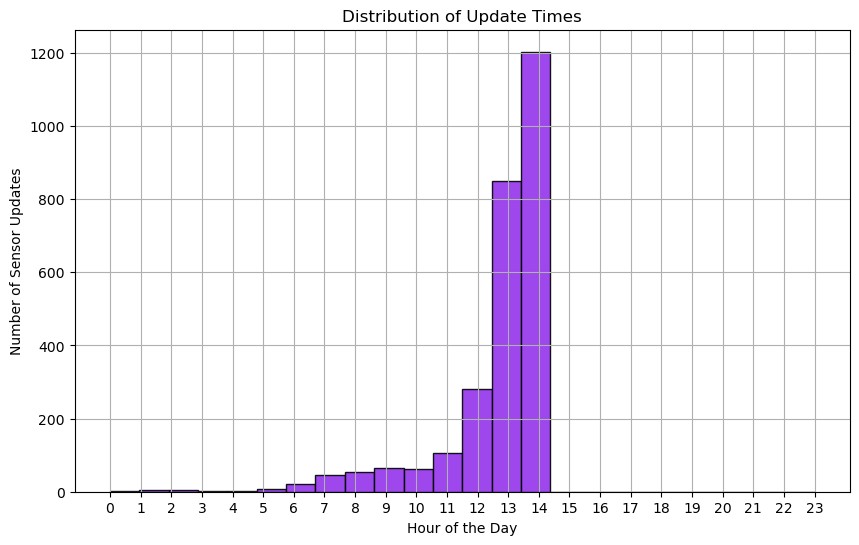

In [28]:
if todays_data.empty:
    print("No data available for the selected date. Cannot perform update time analysis.")
else:
    # Extract the hour from the 'status_timestamp' and create a new column 'update_hour'
    todays_data['update_hour'] = todays_data['status_timestamp'].dt.hour

    # Create a frequency table for the update times
    frequency_table = todays_data['update_hour'].value_counts().sort_index()
    print("Frequency table for update times:")
    print(frequency_table)

    # If there are no update hours, inform the user
    if frequency_table.empty:
        print("No updates have been recorded for the selected date.")
    else:
        # Plot a histogram for the update times
        plt.figure(figsize = (10, 6))
        plt.hist(todays_data['update_hour'], bins = 24, range = (0, 23),
                 edgecolor = 'black', alpha = 0.9, color = '#9333EA')
        plt.xticks(range(24))
        plt.xlabel('Hour of the Day')
        plt.ylabel('Number of Sensor Updates')
        plt.title('Distribution of Update Times')
        plt.grid(True)
        plt.show()

<div id="subsection-6-3" class="usecase-sub-section-heading"><b>6.3. Update times split by status</b></div>

<div class="usecase-body">Splitting the same distribution by status separates two different signals: when bays were being taken, and when they were being freed up. Comparing the two side by side is more informative than the combined view above.</div>

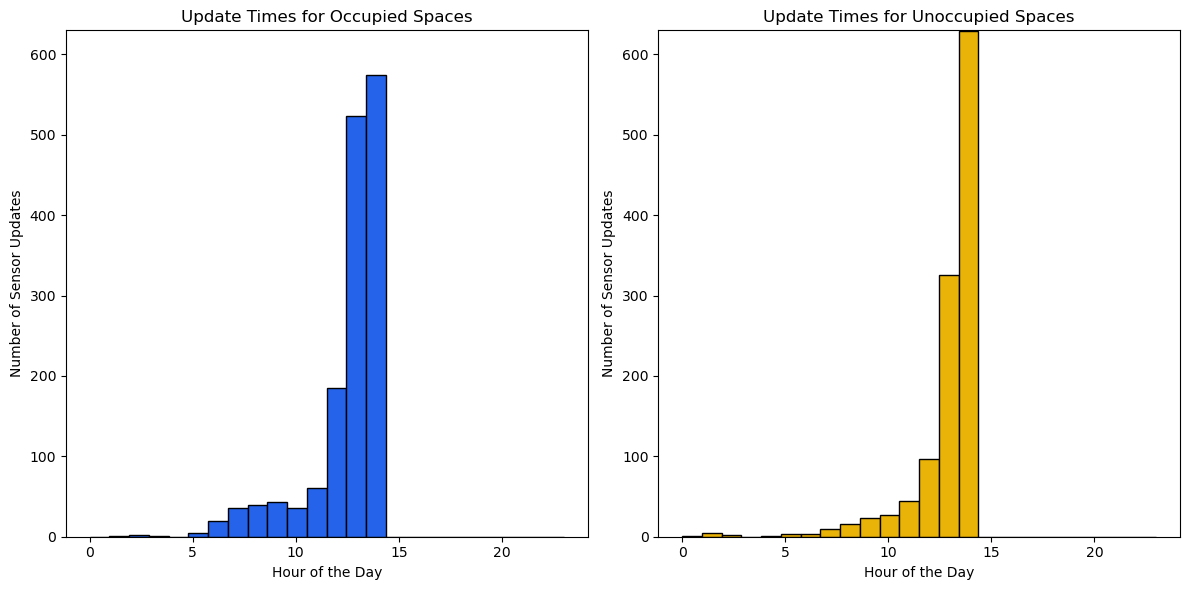

In [29]:
# ensure 'todays_data' contains data
if todays_data.empty:
    print("No data available for the selected date. Cannot perform update time analysis.")
else:
    # Filter data for 'Present' and 'Unoccupied' states
    present_data = todays_data[todays_data['status_description'] == 'Present']
    unoccupied_data = todays_data[todays_data['status_description'] == 'Unoccupied']

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize = (12, 6))

    # Find the maximum frequency to set the same y-axis limit for both subplots
    max_freq_present = present_data['update_hour'].value_counts().max() if not present_data.empty else 0
    max_freq_unoccupied = unoccupied_data['update_hour'].value_counts().max() if not unoccupied_data.empty else 0
    max_frequency = max(max_freq_present, max_freq_unoccupied)

    # Plot histogram for 'Present' state if data is available
    if not present_data.empty:
        axes[0].hist(present_data['update_hour'], bins = 24, edgecolor = 'black',
                     range = (0, 23), color = '#2563EB')
        axes[0].set_ylim([0, max_frequency + 1])
    else:
        axes[0].text(0.5, 0.5, 'No data for Present Spaces',
                     horizontalalignment = 'center', verticalalignment = 'center')
    axes[0].set_title('Update Times for Occupied Spaces')
    axes[0].set_xlabel('Hour of the Day')
    axes[0].set_ylabel('Number of Sensor Updates')

    # Plot histogram for 'Unoccupied' state if data is available
    if not unoccupied_data.empty:
        axes[1].hist(unoccupied_data['update_hour'], bins = 24, edgecolor = 'black',
                     range = (0, 23), color = '#EAB308')
        axes[1].set_ylim([0, max_frequency + 1])
    else:
        axes[1].text(0.5, 0.5, 'No data for Unoccupied Spaces',
                     horizontalalignment = 'center', verticalalignment = 'center')
    axes[1].set_title('Update Times for Unoccupied Spaces')
    axes[1].set_xlabel('Hour of the Day')
    axes[1].set_ylabel('Number of Sensor Updates')

    # Show the plots
    plt.tight_layout()
    plt.show()

<div id="section-7" class="usecase-section-heading"><b>7. Adding parking bay restrictions</b></div>

<div class="usecase-body">A parking space is described across three separate datasets: the sensor, the physical bay, and the restrictions that apply to it. These are maintained by different departments and do not share a single common key, so they have to be joined in two steps — sensors to bays via the kerbside ID, then bays to restrictions via the bay ID.</div>

<div id="subsection-7-1" class="usecase-sub-section-heading"><b>7.1. Retrieve the parking bay dataset</b></div>

<div class="usecase-body">The on-street parking bay dataset is retrieved the same way as the sensor feed. It provides the link between a sensor position and the formal bay identifier used by the restriction data.</div>

In [30]:
# On-street parking bays - links sensor positions to formal bay identifiers
dataset2_id = 'on-street-parking-bays'
base_URL = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
format = 'csv'

url = f'{base_URL}{dataset2_id}/exports/{format}'
params = {
    'select': '*',
    'limit': -1,  # all records
    'lang': 'en',
    'timezone': 'UTC',
}

# GET request
response = requests.get(url, params = params)

if response.status_code == 200:
    # StringIO to read the CSV data
    url_content = response.content.decode('utf-8')
    bay_df = pd.read_csv(StringIO(url_content), delimiter = ';')
    print(bay_df.sample(2, random_state = 999))    # test
else:
    print(f'Request failed with status code {response.status_code}')

       roadsegmentid kerbsideid  \
16800          21015        NaN   
11639          22182      72568   

                                  roadsegmentdescription   latitude  \
16800  Queensberry Street between Curzon Street and A... -37.802645   
11639  Queens Bridge Street between Power Street and ... -37.824271   

        longitude lastupdated                  location  
16800  144.946898  2025-06-03  -37.8026447, 144.9468978  
11639  144.960371  2025-09-03  -37.8242711, 144.9603712  


In [31]:
# check length in dataset
print(f'The dataset contains {len(bay_df)} records.')

The dataset contains 29053 records.


<div id="subsection-7-2" class="usecase-sub-section-heading"><b>7.2. Merge bays onto the sensor data</b></div>

<div class="usecase-body">Columns that already exist in the sensor data are dropped to avoid clashes, non-numeric kerbside IDs are filtered out so the join key is a consistent type, and the two datasets are then merged with a left join so no sensor records are lost.</div>

In [32]:
exclude = ['latitude', 'longitude', 'lastupdated']
bay_selected = bay_df.drop(exclude, axis = 1)

In [33]:
# filtered records to include non-numeric values only
filtered_bay = bay_selected[bay_selected['kerbsideid'].str.isnumeric() != False].copy()

filtered_bay['kerbsideid'] = pd.to_numeric(
    filtered_bay['kerbsideid'], errors = 'coerce').astype('Int64')

In [34]:
# Perform a left merge
merged_df = pd.merge(df_analysis, filtered_bay, on = ['kerbsideid'], how = 'left')
print(merged_df.head(2))

          lastupdated          status_timestamp  zone_number  \
0 2025-10-30 02:45:40 2025-10-20 19:10:02+11:00       7280.0   
1 2025-10-30 02:45:40 2025-10-20 19:14:52+11:00       7280.0   

  status_description  kerbsideid   latitude   longitude status_date  \
0         Unoccupied        5925 -37.811840  144.975773  2025-10-20   
1         Unoccupied        5950 -37.811926  144.976565  2025-10-20   

   roadsegmentid roadsegmentdescription location  
0            NaN                    NaN      NaN  
1            NaN                    NaN      NaN  


In [35]:
merged_df.shape

(5389, 11)

<div class="usecase-body">The merge can introduce duplicates where a kerbside ID appears more than once in the bay dataset, so these are identified and removed before continuing.</div>

In [36]:
# Check duplicated rows based on specific columns
kerb_dup = merged_df.duplicated(subset = ['kerbsideid'], keep = False)

# Display the duplicated rows based on 'kerbsideid'
merged_df[kerb_dup]

,lastupdated,status_timestamp,zone_number,status_description,kerbsideid,latitude,longitude,status_date,roadsegmentid,roadsegmentdescription,location
872,2026-08-24 04:31:40,2026-08-24 11:19:14+10:00,7952.0,Unoccupied,23810,-37.811420,144.953160,2026-08-24,21117.0,Peel Street between Queensberry Street and Eli...,"-37.8015921, 144.956565"
873,2026-08-24 04:31:40,2026-08-24 11:19:14+10:00,7952.0,Unoccupied,23810,-37.811420,144.953160,2026-08-24,21514.0,Jeffcott Street between Spencer Street and Kin...,"-37.811407, 144.9531655"
877,2026-08-24 04:31:40,2026-08-24 14:03:59+10:00,7938.0,Unoccupied,23854,-37.811789,144.952270,2026-08-24,22452.0,Harbour Esplanade between Bourke Street and La...,"-37.8159499, 144.9454832"
878,2026-08-24 04:31:40,2026-08-24 14:03:59+10:00,7938.0,Unoccupied,23854,-37.811789,144.952270,2026-08-24,21514.0,Jeffcott Street between Spencer Street and Kin...,"-37.8117762, 144.9522759"
882,2026-08-24 04:31:40,2026-08-24 13:53:15+10:00,7952.0,Present,23811,-37.811437,144.953101,2026-08-24,21514.0,Jeffcott Street between Spencer Street and Kin...,"-37.8114236, 144.9531067"
883,2026-08-24 04:31:40,2026-08-24 13:53:15+10:00,7952.0,Present,23811,-37.811437,144.953101,2026-08-24,21117.0,Peel Street between Queensberry Street and Eli...,"-37.8016456, 144.9565555"
1244,2026-08-24 04:31:40,2026-08-24 14:16:44+10:00,NaN,Present,22418,-37.806622,144.965127,2026-08-24,20739.0,Orr Street between Victoria Street and Earl St...,"-37.8066087, 144.9651329"
1245,2026-08-24 04:31:40,2026-08-24 14:16:44+10:00,NaN,Present,22418,-37.806622,144.965127,2026-08-24,22308.0,Commercial Road between St Kilda Road and Punt...,"-37.844975, 144.9804527"
1354,2026-08-24 04:31:40,2026-08-15 21:37:11+10:00,7012.0,Unoccupied,17212,-37.803819,144.959413,2026-08-15,22630.0,Wellington Parade South between Wellington Cre...,"-37.8160071, 144.9753201"
1355,2026-08-24 04:31:40,2026-08-15 21:37:11+10:00,7012.0,Unoccupied,17212,-37.803819,144.959413,2026-08-15,20472.0,Berkeley Street between Queensberry Street and...,"-37.8038058, 144.9594192"


In [37]:
# Drop duplicated rows based on 'kerbsideid'
merged_df = merged_df.drop_duplicates(subset=['kerbsideid'], keep='first')
print(merged_df.shape)

(5370, 11)


<div class="usecase-body">Counting the sensors that failed to match a bay shows how complete the join actually was — an important caveat on any conclusion drawn from the restriction data.</div>

In [38]:
# Count the number of NaN values in the 'kerbsideid' column
num_nan = merged_df['kerbsideid'].isna().sum()

print(f"There are {num_nan} NaN values in the 'kerbsideid' column.")

There are 0 NaN values in the 'kerbsideid' column.


In [39]:
# Filter to only include the analysis date, using .copy() to avoid a SettingWithCopyWarning
todays_data = merged_df[merged_df['status_date'] == analysis_date].copy()

# Count the number of NaN values in the 'kerbsideid' column for the selected date
num_nan_today = todays_data['kerbsideid'].isna().sum()

print(f"There are {num_nan_today} NaN values in the 'kerbsideid' column for {analysis_date}.")

There are 0 NaN values in the 'kerbsideid' column for 2026-08-24.


<div id="subsection-7-3" class="usecase-sub-section-heading"><b>7.3. Retrieve the restriction descriptions</b></div>

<div class="usecase-body">The restriction dataset describes the rules applying to each bay, such as time limits and permit conditions.</div>

In [40]:
# On-street car park bay restrictions - time limits and permit conditions
dataset3_id = 'on-street-car-park-bay-restrictions'
base_URL = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
format = 'csv'

url = f'{base_URL}{dataset3_id}/exports/{format}'
params = {
    'select': '*',
    'limit': -1,  # all records
    'lang': 'en',
    'timezone': 'UTC',
}

# GET request
response = requests.get(url, params = params)

if response.status_code == 200:
    # StringIO to read the CSV data
    url_content = response.content.decode('utf-8')
    restrictions = pd.read_csv(StringIO(url_content), delimiter = ';')
    print(restrictions.sample(2, random_state = 999))    # test
else:
    print(f'Request failed with status code {response.status_code}')

      bayid  deviceid             description1            description2  \
540    7928     25298     2P M-SAT 7:30AM-10PM  2P DIS SUN 7:30AM-10PM   
2353   3544     29012  3P MTR M-SAT 7:30-20:30                     NaN   

     description3 description4 description5 description6  disabilityext1  \
540           NaN          NaN          NaN          NaN             240   
2353          NaN          NaN          NaN          NaN             360   

      disabilityext2  ...  today3  today4  today5  today6  typedesc1  \
540              0.0  ...     NaN     NaN     NaN     NaN         2P   
2353             NaN  ...     NaN     NaN     NaN     NaN   3P Meter   

             typedesc2  typedesc3  typedesc4  typedesc5  typedesc6  
540   2P Disabled Only        NaN        NaN        NaN        NaN  
2353               NaN        NaN        NaN        NaN        NaN  

[2 rows x 62 columns]


In [41]:
# check length in dataset 3

print(f'The dataset contains {len(restrictions)} records.')

The dataset contains 4263 records.


<div id="subsection-7-4" class="usecase-sub-section-heading"><b>7.4. Merge the restrictions</b></div>

<div class="usecase-body">Only the description columns 1 to 5 are used. Description 6 is documented as a time limit field, but in practice it is populated with a placeholder date of 1 January AD1 and carries no usable information, so it is excluded. The restriction dataset also names its key <code>bayid</code> rather than <code>kerbsideid</code>, so it is renamed before joining.</div>

In [42]:
# rename the 'bayid' column as'kerbsideid'
restrictions.rename(columns = {'bayid': 'kerbsideid'}, inplace = True)

In [43]:
# Merge merged_df with only the relevant columns from restrictions
columns_to_merge = ['kerbsideid', 'description1', 'description2',
                    'description3', 'description4', 'description5']
merged_df = pd.merge(
    merged_df,
    restrictions[columns_to_merge],
    left_on = 'kerbsideid',
    right_on = 'kerbsideid',
    how = 'left')

In [44]:
print(merged_df.head(2))

          lastupdated          status_timestamp  zone_number  \
0 2025-10-30 02:45:40 2025-10-20 19:10:02+11:00       7280.0   
1 2025-10-30 02:45:40 2025-10-20 19:14:52+11:00       7280.0   

  status_description  kerbsideid   latitude   longitude status_date  \
0         Unoccupied        5925 -37.811840  144.975773  2025-10-20   
1         Unoccupied        5950 -37.811926  144.976565  2025-10-20   

   roadsegmentid roadsegmentdescription location description1 description2  \
0            NaN                    NaN      NaN          NaN          NaN   
1            NaN                    NaN      NaN          NaN          NaN   

  description3 description4 description5  
0          NaN          NaN          NaN  
1          NaN          NaN          NaN  


<div id="subsection-7-5" class="usecase-sub-section-heading"><b>7.5. Separate out disabled parking bays</b></div>

<div class="usecase-body">Bays marked "DIS" are disabled parking bays. These are reserved for permit holders and are not available to general traffic, so including them would overstate how much parking is genuinely on offer. They are separated into their own DataFrame rather than discarded, so they remain available for inspection.</div>

<div class="usecase-body">The <code>na=False</code> argument matters here. Without it, <code>str.contains</code> returns a missing value for every bay with no description rather than <code>False</code>, and those missing values then propagate through the row-wise check — which either raises an error or quietly misclassifies bays that simply have no restriction recorded. Setting it explicitly means "no description" is correctly treated as "not a disabled bay".</div>

In [45]:
# Columns to check for "DIS"
columns_to_check = ['description1', 'description2', 'description3', 'description4', 'description5']

# Find rows where any of the specified columns contain "DIS".
# na=False treats a missing description as "not a disabled bay" rather than an unknown.
contains_dis = merged_df[columns_to_check].apply(
    lambda x: x.str.contains('DIS', na = False)
).any(axis = 1)

# Extract rows with "DIS" into a separate DataFrame
disabled_parking_df = merged_df[contains_dis]

# Delete rows with "DIS" from the original DataFrame
merged_df = merged_df[~contains_dis]

# Display the new DataFrames
print("Disabled Parking Data:")
print(disabled_parking_df.head())

print("Remaining Data:")
print(merged_df.head())

Disabled Parking Data:
             lastupdated          status_timestamp  zone_number  \
1617 2026-08-24 04:31:40 2026-03-10 13:41:11+11:00       7239.0   

     status_description  kerbsideid   latitude   longitude status_date  \
1617            Present        7855 -37.809966  144.978853  2026-03-10   

      roadsegmentid roadsegmentdescription location  \
1617            NaN                    NaN      NaN   

                    description1          description2  \
1617  P DISABLE AOT 0:00 TO 7:30  2P DIS 7.30 - 8.30PM   

                  description3 description4 description5  
1617  P DIS AOT 8:31PM-11:59PM          NaN          NaN  
Remaining Data:
          lastupdated          status_timestamp  zone_number  \
0 2025-10-30 02:45:40 2025-10-20 19:10:02+11:00       7280.0   
1 2025-10-30 02:45:40 2025-10-20 19:14:52+11:00       7280.0   
2 2025-10-30 02:45:40 2025-10-20 17:35:18+11:00       7278.0   
3 2025-10-30 02:45:40 2025-10-20 19:07:08+11:00       7278.0   
4 2025-10-3

<div id="subsection-7-6" class="usecase-sub-section-heading"><b>7.6. How complete is the restriction data?</b></div>

<div class="usecase-body">Counting the bays with no restriction description at all shows how much of the restriction data is actually missing, which directly determines whether real time limits can be used in section 8 or whether an assumption is needed instead.</div>

In [46]:
# Columns to check for NaN values
columns_to_check = ['description1', 'description2', 'description3', 'description4', 'description5']

# Find rows where all specified columns are NaN
all_nan_rows = merged_df[columns_to_check].isna().all(axis = 1)

# Count the number of such rows
num_all_nan_rows = all_nan_rows.sum()

# Display the count
print(f"Number of rows where all of the specified columns are NaN: {num_all_nan_rows}")

Number of rows where all of the specified columns are NaN: 5346


<div class="usecase-list">

- The bay ID and restriction details have been joined onto each sensor record without losing any sensor rows.
- Most bays covered by a sensor have no time limit recorded, which does not match what is actually signposted on the street.
- The three datasets come from three different systems, so gaps of this kind are expected when combining them.

</div>

<div class="usecase-body">Because the real time limits are largely unavailable, section 8 works from an explicit assumption instead. This is a limitation of the source data rather than of the method, and it is the main reason the hotspots produced below are described as theoretical.</div>

<div id="section-8" class="usecase-section-heading"><b>8. Estimating parking hotspots</b></div>

<div class="usecase-body">This final section brings everything together to answer the original questions: where the hotspots are, and whether they are still building or have started to ease.</div>

<div class="usecase-body">Since time limits are largely missing from the data, a two-hour limit is assumed with an average stay of one hour. The snapshot only records when a bay became vacant, not when it was taken, so shifting each vacancy back by one hour gives an estimated parking start time. This is an assumption rather than a measurement, and the results below should be read with that in mind.</div>

<div id="subsection-8-1" class="usecase-sub-section-heading"><b>8.1. Estimating when each space was taken</b></div>

<div class="usecase-body">Each vacant reading is shifted back by one hour to approximate when that bay was most likely occupied, and any record that moves outside the analysis date is dropped so the day's figures stay internally consistent.</div>

In [47]:
# Step 1: Create a copy of the selected day's data
todays_data_copy = todays_data.copy()

# Step 2: Filter to only include rows where the parking space is vacant
vacant_indices = todays_data_copy[todays_data_copy['status_description'] == 'Unoccupied'].index

# Step 3: Subtract 60 minutes from the timestamp of these vacant spaces
todays_data_copy.loc[vacant_indices, 'status_timestamp'] = todays_data_copy.loc[
    vacant_indices, 'status_timestamp'] - Minute(60)

# Step 4: Update the 'status_date' column based on the new 'status_timestamp'
todays_data_copy['status_date'] = todays_data_copy['status_timestamp'].dt.date

# Step 5: Change the status of these advanced-time vacant spaces to 'Occupied'
todays_data_copy.loc[vacant_indices, 'status_description'] = 'Occupied'

# Step 6: Remove rows that have moved outside the analysis date
todays_data_copy = todays_data_copy[todays_data_copy['status_date'] == analysis_date]

<div id="subsection-8-2" class="usecase-sub-section-heading"><b>8.2. Popular parking hours</b></div>

<div class="usecase-body">Plotting the estimated occupancy times by hour shows the shape of the day. If the count is still climbing, hotspots are likely still building; if it has started to fall, they have probably begun to ease — which is the second question posed in the scenario at the start.</div>

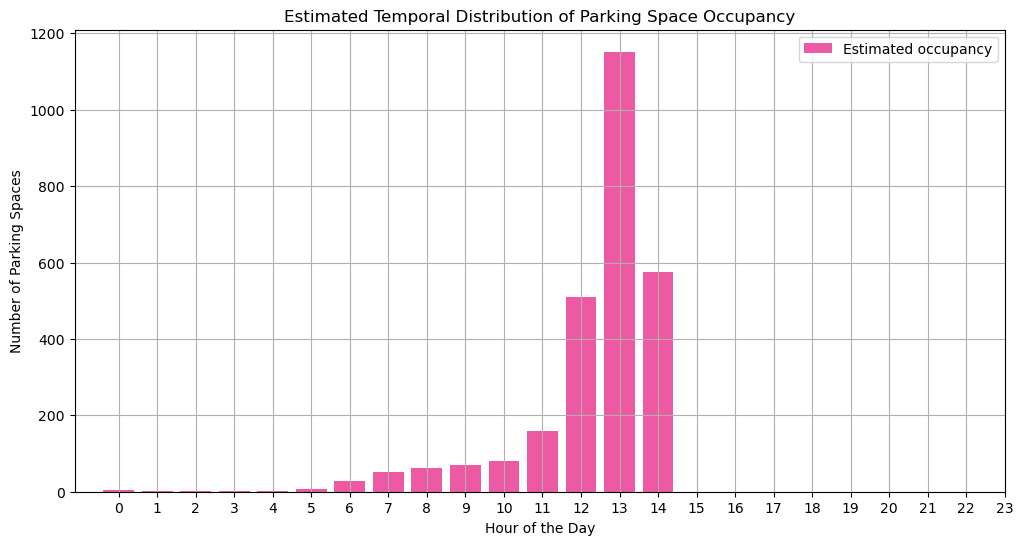

In [48]:
# Convert 'status_timestamp' to just the hour of the day
todays_data_copy['status_hour'] = todays_data_copy['status_timestamp'].dt.hour

# Create a frequency table for the update times
frequency_table = todays_data_copy['status_hour'].value_counts().sort_index()

# Plot a bar chart for the estimated occupancy times
plt.figure(figsize = (12, 6))
plt.bar(frequency_table.index, frequency_table.values,
        color = '#EC4899', alpha = 0.9, label = 'Estimated occupancy')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Parking Spaces')
plt.title('Estimated Temporal Distribution of Parking Space Occupancy')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.show()

<div id="subsection-8-3" class="usecase-sub-section-heading"><b>8.3. Clustering the hotspots on a map</b></div>

<div class="usecase-body">DBSCAN is used to group nearby occupied bays into clusters, which answers the first question from the scenario by showing where parking pressure is concentrated rather than plotting every bay individually. DBSCAN suits this well because it finds dense groups without needing the number of clusters specified in advance, and labels isolated bays as noise rather than forcing them into a group. The <code>eps</code> value of 0.0005 degrees is roughly 50 metres, and at least 20 bays are required before an area counts as a hotspot.</div>

In [49]:
# Create a new DataFrame with only the latitude and longitude columns
X = todays_data_copy[['latitude', 'longitude']].values

# Run DBSCAN clustering
dbscan = DBSCAN(eps = 0.0005, min_samples = 20)
labels = dbscan.fit_predict(X)

# Add cluster labels back to DataFrame
todays_data_copy['cluster_label'] = labels

# Calculate the centroid of each cluster
cluster_centroids = todays_data_copy.groupby('cluster_label').agg(
    {'latitude': 'mean', 'longitude': 'mean'}).reset_index()

# Initialize the map
m = folium.Map(location = [-37.814, 144.963], zoom_start = 16)

# Add circles for each cluster
for idx, row in cluster_centroids.iterrows():
    if row['cluster_label'] != -1:  # -1 is the label for noise points in DBSCAN
        folium.Circle(
            location = [row['latitude'], row['longitude']],
            radius = 50,  # Radius in metres
            color = '#059669',
            fill = True,
            fill_color = '#059669'
        ).add_to(m)

legend_html = """
<div style="position: fixed;
            bottom: 40px; left: 40px; width: 210px;
            background-color: rgba(255, 255, 255, 0.9); border:2px solid grey; z-index:1000; font-size:14px;
            padding: 10px;">
<b>Legend</b><br>
<i style="background:#059669; width:10px; height:10px; display:inline-block; border-radius:50%;"></i>
&nbsp;Estimated parking hotspot
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Show the map
m

<div class="usecase-body">Each circle marks an area where a high number of bays were estimated to be occupied at the same time, which is the practical answer to the scenario: these are the parts of the city where a driver is least likely to find a space, and worth avoiding in favour of the surrounding streets.</div>

<div id="conclusion" class="usecase-unnumbered-heading"><b>Conclusion</b></div>

<div class="usecase-body">This use case combined three separate City of Melbourne datasets to estimate where parking hotspots form in the city centre and at what time of day they build up. Because the sensor feed carries no history, and because the restriction data is largely incomplete, the hotspots identified are theoretical rather than measured, and will differ from the situation on the ground.</div>

<div class="usecase-sub-section-heading"><b>What we achieved in this analysis</b></div>

<div class="usecase-body">Three datasets maintained by different departments were retrieved, cleaned and joined into a single working dataset, despite inconsistent keys and substantial missing values. From that, the day's parking activity was mapped, the hourly pattern of occupancy was reconstructed from a single snapshot, and DBSCAN clustering was used to identify the areas of highest parking pressure.</div>

<div class="usecase-sub-section-heading"><b>What we learned from this analysis</b></div>

<div class="usecase-body">The main lesson is how much the shape of the source data constrains what can be claimed. Snapshot data cannot support genuine time-series analysis, so activity had to be estimated through an explicit assumption instead. Combining datasets across departments also proved harder than expected, with the restriction data missing for most bays covered by a sensor. Recognising and documenting these limits mattered more to the integrity of the result than any individual analysis step.</div>

<div class="usecase-sub-section-heading"><b>Observations for further opportunities</b></div>

<div class="usecase-body">Genuine longitudinal analysis would require polling and storing the sensor feed continuously over time, which is beyond what a reader can reproduce in a notebook but well within reach of a small scheduled service. If the restriction dataset were completed, real time limits could replace the assumed two-hour limit and materially improve accuracy. Beyond that, the clustering approach could be extended to compare hotspots across days of the week, or combined with event and public transport data to explain why particular areas fill up when they do.</div>